# Variance, Standard Deviation , IQR, Outlier Detection

---

# 1. Introduction

In data analysis, understanding the **center** of the data is only the first step. Equally important is understanding **how the data is distributed around that center**.

Consider two datasets with the same average value. One dataset may have values that are very close to the mean, while the other may have values spread over a much wider range. Although both datasets have the same average, they represent very different situations. This difference is captured by **measures of dispersion**.

Measures such as **Variance**, **Standard Deviation**, and **Interquartile Range (IQR)** help us quantify the spread of the data, while **Outlier Detection** helps identify observations that are significantly different from the majority of the data.

These concepts are fundamental in statistics because they help answer questions such as:

- How consistent is the data?
- How much do observations vary from the average?
- Are there any unusual or extreme values?
- Is the dataset reliable for analysis and machine learning?

Understanding these measures is essential for **Exploratory Data Analysis (EDA)**, **Machine Learning**, **Data Cleaning**, **Anomaly Detection**, and **Business Decision Making**.

# 2. Intuition

Imagine you are analyzing the marks of students in a class.

```
45, 48, 50, 52, 53, 55
```

At first glance, these marks are **close to one another**. This means the students performed consistently.

Now consider another class:

```
10, 30, 50, 70, 90, 110
```

Although the average marks might be similar, the students' performance varies significantly.

This raises an important question:

> **How do we measure how spread out the data is?**

Measures of dispersion help answer this question.

- **Variance** measures the average squared distance of each observation from the mean.
- **Standard Deviation** converts the variance back into the original units, making it easier to interpret.
- **Interquartile Range (IQR)** focuses only on the middle 50% of the data, making it resistant to outliers.
- **Outlier Detection** identifies observations that are unusually far from the rest of the data.

These measures help us understand whether the data is **consistent, highly variable, or contains unusual observations.**

---

## Why can't we just use the Mean?

The mean tells us the **center** of the data, but it tells us nothing about how the data is distributed around that center.

For example:

Dataset A

```
48, 49, 50, 51, 52
```

Mean = **50**

Dataset B

```
20, 35, 50, 65, 80
```

Mean = **50**

Although both datasets have the same mean, Dataset B is much more spread out.

Measures of dispersion help distinguish between these situations.

---

## Why do we need different measures?

Different measures answer different questions:

- **Variance** tells us the overall variability by considering every observation.
- **Standard Deviation** expresses that variability in the original units of the data.
- **IQR** measures the spread of the middle 50% of observations.
- **Outlier Detection** helps identify observations that are unusually different from the rest of the dataset.

Together, these measures provide a complete understanding of the variability in the data.

# 3. Mathematical Formulae

## 1. Variance

Variance measures the average squared deviation of each observation from the mean.

### Population Variance

$$
\sigma^2=\frac{\sum_{i=1}^{N}(x_i-\mu)^2}{N}
$$

### Sample Variance

$$
s^2=\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}
$$

**Where:**

- $x_i$ = Individual observation
- $\mu$ = Population mean
- $\bar{x}$ = Sample mean
- $N$ = Population size
- $n$ = Sample size

---

## 2. Standard Deviation

Standard deviation is the square root of the variance.

### Population Standard Deviation

$$
\sigma=\sqrt{\frac{\sum_{i=1}^{N}(x_i-\mu)^2}{N}}
$$

### Sample Standard Deviation

$$
s=\sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}
$$

**Where:**

- $\sigma$ = Population Standard Deviation
- $s$ = Sample Standard Deviation

---

## 3. Interquartile Range (IQR)

The Interquartile Range measures the spread of the middle 50% of the data.

$$
IQR = Q_3 - Q_1
$$

**Where:**

- $Q_1$ = First Quartile (25th percentile)
- $Q_3$ = Third Quartile (75th percentile)

---

## 4. Outlier Detection using IQR

### Lower Bound

$$
\text{Lower Bound}=Q_1-1.5\times IQR
$$

### Upper Bound

$$
\text{Upper Bound}=Q_3+1.5\times IQR
$$

Any observation satisfying

$$
x < Q_1-1.5\times IQR
$$

or

$$
x > Q_3+1.5\times IQR
$$

is considered a **potential outlier**.

---

## Summary

| Measure | Formula |
|----------|---------|
| Variance | $s^2=\frac{\sum(x_i-\bar{x})^2}{n-1}$ |
| Standard Deviation | $s=\sqrt{\frac{\sum(x_i-\bar{x})^2}{n-1}}$ |
| IQR | $Q_3-Q_1$ |
| Lower Bound | $Q_1-1.5\times IQR$ |
| Upper Bound | $Q_3+1.5\times IQR$ |

# 4. Import Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
data = [45, 48, 50, 52, 53, 55, 95]

# NumPy Array
arr = np.array(data)

# Pandas DataFrame
df = pd.DataFrame({"Marks": data})

# 5. Python Implementation




ddof stands for Delta Degrees of Freedom.

The divisor used is:

N−ddof

ddof=0 → divide by N (Population Variance)

ddof=1 → divide by N−1 (Sample Variance)

| Library           | Default             | Denominator | Use Case                       |
| ----------------- | ------------------- | ----------- | ------------------------------ |
| `np.var()`        | Population Variance | **N**       | Entire dataset is available    |
| `pd.Series.var()` | Sample Variance     | **N−1**     | Dataset is treated as a sample |
| `np.std()`        | Population SD       | **N**       | Entire population              |
| `pd.Series.std()` | Sample SD           | **N−1**     | Sample statistics              |



## 1️⃣ Variance

### Using NumPy


In [53]:
# Population Variance (Default)
np.var(arr)

np.float64(251.83673469387756)

In [9]:
# Sample Variance
np.var(arr, ddof=1)

np.float64(293.8095238095238)


## Using Pandas


In [11]:
# Sample Variance (Default)
df["Marks"].var()

293.8095238095238

In [12]:
# Population Variance
df["Marks"].var(ddof=0)

251.83673469387756

## 2️⃣ Standard Deviation

### Using NumPy

In [13]:
# Population Standard Deviation
np.std(arr)

np.float64(15.869364659427218)

In [14]:
# Sample Standard Deviation
np.std(arr, ddof=1)

np.float64(17.14087290103756)

### Using Pandas


In [16]:
# Sample Standard Deviation (Default)
df["Marks"].std()


17.14087290103756

In [18]:
# Population Standard Deviation
df["Marks"].std(ddof=0)


15.869364659427218

## 3️⃣ Quartiles

### Using NumPy


In [20]:
Q1 = np.percentile(arr, 25)
Q2 = np.percentile(arr, 50)
Q3 = np.percentile(arr, 75)

print(Q1, Q2, Q3)

49.0 52.0 54.0


### Using Pandas

In [22]:
Q1 = df["Marks"].quantile(0.25)
Q2 = df["Marks"].quantile(0.50)
Q3 = df["Marks"].quantile(0.75)

print(Q1, Q2, Q3)

49.0 52.0 54.0


## 4️⃣ Interquartile Range (IQR)

### Using NumPy


In [23]:
Q1 = np.percentile(arr, 25)
Q3 = np.percentile(arr, 75)

IQR = Q3 - Q1

print(IQR)


5.0


### Using Pandas

In [ ]:
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

print(IQR)

## 5️⃣ Outlier Detection (IQR Method)

### Using NumPy

In [24]:
Q1 = np.percentile(arr, 25)
Q3 = np.percentile(arr, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = arr[(arr < lower_bound) | (arr > upper_bound)]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Outliers:", outliers)

Lower Bound: 41.5
Upper Bound: 61.5
Outliers: [95]


### Using Pandas

In [25]:
Q1 = df["Marks"].quantile(0.25)
Q3 = df["Marks"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Marks"] < lower_bound) |
    (df["Marks"] > upper_bound)
]

print(outliers)

   Marks
6     95


## 6️⃣ Remove Outliers

### NumPy


In [26]:
clean_data = arr[
    (arr >= lower_bound) &
    (arr <= upper_bound)
]

print(clean_data)


[45 48 50 52 53 55]


### Pandas

In [27]:
clean_df = df[
    (df["Marks"] >= lower_bound) &
    (df["Marks"] <= upper_bound)
]

print(clean_df)


   Marks
0     45
1     48
2     50
3     52
4     53
5     55


### Summary

| Measure | NumPy Function | Pandas Function |
|----------|----------------|-----------------|
| Variance | `np.var()` | `Series.var()` |
| Standard Deviation | `np.std()` | `Series.std()` |
| Quartiles | `np.percentile()` | `Series.quantile()` |
| IQR | `np.percentile()` | `Series.quantile()` |
| Outliers | Boolean Indexing | Boolean Indexing |

---

# 📈 6. Visualization



# 1️⃣ Histogram

A histogram shows how frequently values occur in different intervals. It helps us understand the distribution and spread of the data.


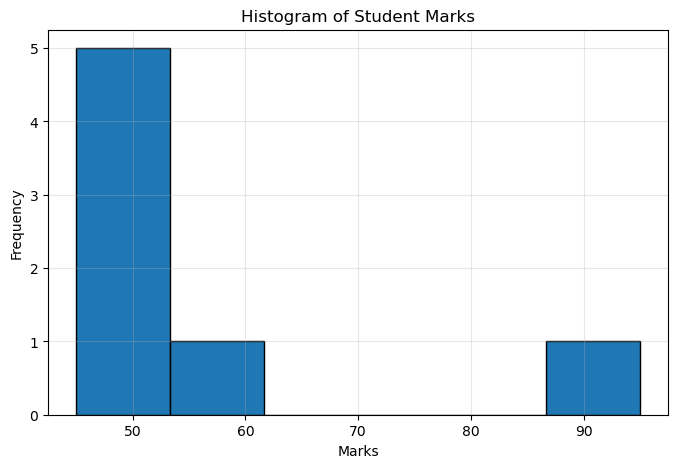

In [30]:
plt.figure(figsize=(8,5))

plt.hist(df["Marks"], bins=6, edgecolor="black")

plt.title("Histogram of Student Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- Most students scored between **45 and 55**.
- The score **95** is much higher than the others and appears isolated.
- This suggests a possible outlier.
- The distribution is positively skewed because of the unusually high score.

---

# 2️⃣ Histogram with Mean and Standard Deviation


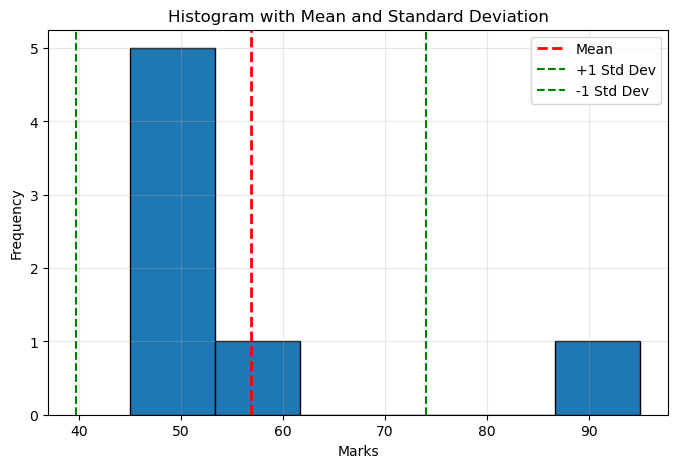

In [31]:
mean = df["Marks"].mean()
std = df["Marks"].std()

plt.figure(figsize=(8,5))

plt.hist(df["Marks"], bins=6, edgecolor="black")

plt.axvline(mean, color="red", linestyle="--", linewidth=2, label="Mean")

plt.axvline(mean + std, color="green", linestyle="--", label="+1 Std Dev")

plt.axvline(mean - std, color="green", linestyle="--", label="-1 Std Dev")

plt.title("Histogram with Mean and Standard Deviation")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- The red line represents the average marks.
- The green lines show one standard deviation above and below the mean.
- Most observations lie near the mean.
- The value **95** lies far from the average, increasing the standard deviation.

---

# 3️⃣ Box Plot

A box plot summarizes the data using Quartiles and clearly highlights outliers.


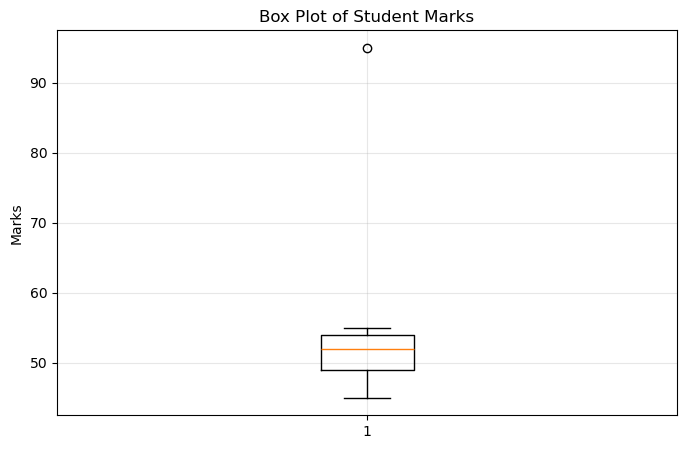

In [32]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Marks"], vert=True)

plt.title("Box Plot of Student Marks")
plt.ylabel("Marks")

plt.grid(alpha=0.3)

plt.show()


- The box represents the middle 50% of the data (IQR).
- The line inside the box represents the Median.
- The whiskers represent the normal range of the data.
- Any point outside the whiskers is considered a potential outlier.
- Here, the value **95** is identified as an outlier.

---

# 🚢 7. Real Dataset Example (Titanic)



In [34]:
df = pd.read_csv(r"C:\Users\TEMP.CLOUDNINE\Documents\Shalini\Data Science\Notebooks\Datasets\Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [36]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [38]:
age = df['Age'].dropna()
fare = df['Fare']

### Variance

In [40]:
print("Age Variance (Sample):", age.var())
print("Age Variance (Population):", age.var(ddof=0))
print("Fare Variance (Sample):", fare.var())
print("Fare Variance (Population):", fare.var(ddof=0))

Age Variance (Sample): 211.0191247463081
Age Variance (Population): 210.7235797536662
Fare Variance (Sample): 2469.436845743117
Fare Variance (Population): 2466.6653116850434


### Standard Deviation

In [41]:
print("Age Standard Deviation:", age.std())
print("Population Standard Deviation:", age.std(ddof=0))
print("Fare Standard Deviation:", fare.std())
print("Population Standard Deviation:", fare.std(ddof=0))

Age Standard Deviation: 14.526497332334044
Population Standard Deviation: 14.516321150817317
Fare Standard Deviation: 49.693428597180905
Population Standard Deviation: 49.66553444477411


### Quartiles

In [42]:
Q1_age = age.quantile(0.25)
Q2_age = age.quantile(0.50)
Q3_age = age.quantile(0.75)
print(Q1_age, Q2_age, Q3_age)

Q1_fare = fare.quantile(0.25)
Q2_fare = fare.quantile(0.50)
Q3_fare = fare.quantile(0.75)
print(Q1_fare, Q2_fare, Q3_fare)

20.125 28.0 38.0
7.9104 14.4542 31.0


### IQR

In [43]:
IQR_age = Q3_age - Q1_age
print(IQR_age)

IQR_fare = Q3_fare - Q1_fare
print(IQR_fare)

17.875
23.0896


### Outliers Detection

In [44]:
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["Age"] < lower_age) |
    (df["Age"] > upper_age)
]

print(age_outliers[["PassengerId","Age"]])


lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df["Fare"] < lower_fare) |
    (df["Fare"] > upper_fare)
]

print(fare_outliers[["PassengerId","Fare"]])



     PassengerId   Age
33            34  66.0
54            55  65.0
96            97  71.0
116          117  70.5
280          281  65.0
456          457  65.0
493          494  71.0
630          631  80.0
672          673  70.0
745          746  70.0
851          852  74.0
     PassengerId      Fare
1              2   71.2833
27            28  263.0000
31            32  146.5208
34            35   82.1708
52            53   76.7292
..           ...       ...
846          847   69.5500
849          850   89.1042
856          857  164.8667
863          864   69.5500
879          880   83.1583

[116 rows x 2 columns]


### Remove Outliers

In [45]:
clean_fare = df[
    (df["Fare"] >= lower_fare) &
    (df["Fare"] <= upper_fare)
]

clean_fare.head()

clean_age = df[
    (df["Age"] >= lower_age) &
    (df["Age"] <= upper_age)
]

clean_age.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [46]:
summary = pd.DataFrame({
    "Variance":[age.var(),fare.var()],
    "Std Dev":[age.std(),fare.std()],
    "Q1":[Q1_age,Q1_fare],
    "Median":[Q2_age,Q2_fare],
    "Q3":[Q3_age,Q3_fare],
    "IQR":[IQR_age,IQR_fare]
},index=["Age","Fare"])

summary

,Variance,Std Dev,Q1,Median,Q3,IQR
Age,211.019125,14.526497,20.1250,28.0000,38.0,17.8750
Fare,2469.436846,49.693429,7.9104,14.4542,31.0,23.0896


# 🔍 Interpretation

### Age

- The Age column has a moderate standard deviation, indicating that passenger ages are reasonably spread around the average.
- Most passengers fall within the IQR, while a few extremely young or elderly passengers are detected as potential outliers.

### Fare

- The Fare column has a much larger variance and standard deviation than Age.
- This indicates that ticket prices vary significantly among passengers.
- The box plot identifies several high-fare passengers as outliers. These passengers likely traveled in higher-class cabins or purchased premium tickets.
- The Fare distribution is positively skewed due to these high-value observations.



# 📊 8. Visualization on Titanic Dataset



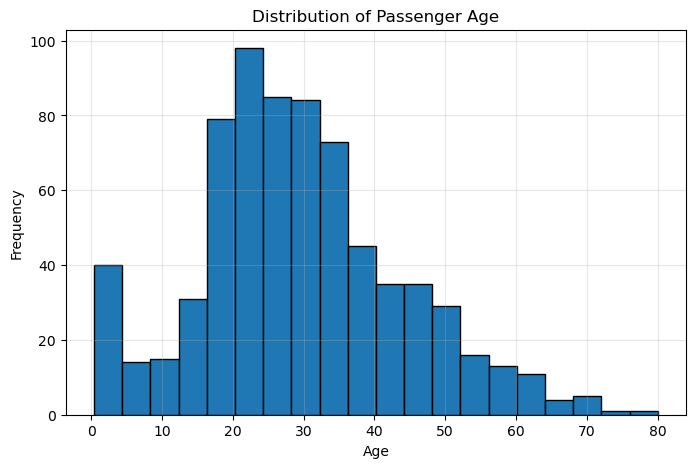

In [47]:
plt.figure(figsize=(8,5))

plt.hist(age, bins=20, edgecolor="black")

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- Most passengers were between **20 and 40 years old**.
- Very young and elderly passengers are less common.
- The distribution is slightly right-skewed.
- Passenger ages show moderate variability.

---

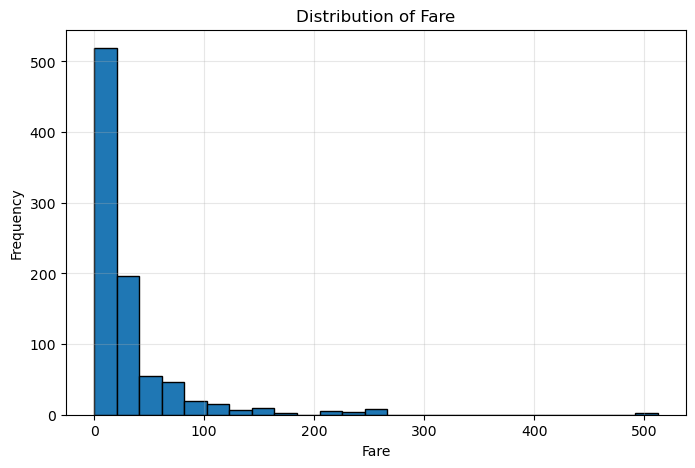

In [48]:
plt.figure(figsize=(8,5))

plt.hist(fare, bins=25, edgecolor="black")

plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- Most passengers paid relatively low fares.
- A small number paid very high fares.
- The Fare distribution is highly right-skewed.
- High-ticket fares increase the overall variance and standard deviation.

---

### Histogram with Mean and Standard Deviation (Fare)


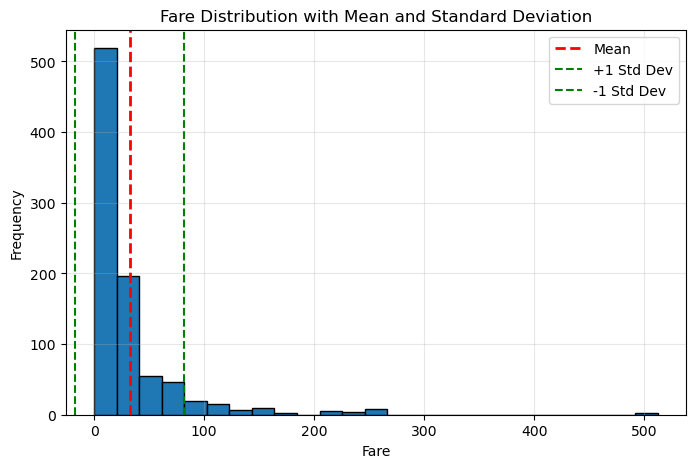

In [50]:

mean_fare = fare.mean()
std_fare = fare.std()

plt.figure(figsize=(8,5))

plt.hist(fare, bins=25, edgecolor="black")

plt.axvline(mean_fare, color="red", linestyle="--", linewidth=2, label="Mean")
plt.axvline(mean_fare + std_fare, color="green", linestyle="--", label="+1 Std Dev")
plt.axvline(mean_fare - std_fare, color="green", linestyle="--", label="-1 Std Dev")

plt.title("Fare Distribution with Mean and Standard Deviation")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


### Interpretation

- Most passengers paid fares much lower than the average.
- A few expensive tickets increase both the mean and the standard deviation.
- The Fare distribution has much greater variability than Age.

---

#### Box Plot of Age

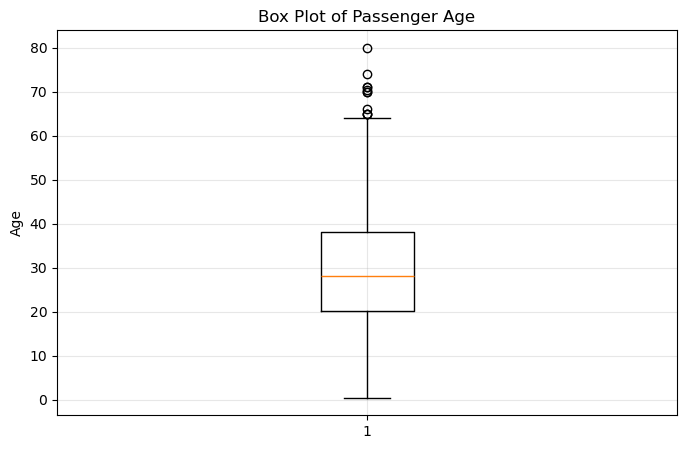

In [51]:
plt.figure(figsize=(8,5))

plt.boxplot(age)

plt.title("Box Plot of Passenger Age")
plt.ylabel("Age")

plt.grid(alpha=0.3)

plt.show()

### Interpretation

- The box represents the middle 50% of passenger ages.
- The median age lies inside the box.
- Only a few passengers appear as potential outliers.

---

#### Box Plot of Fare

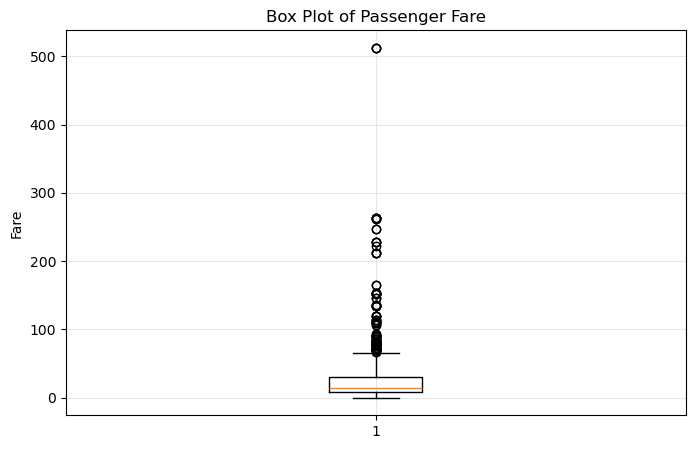

In [52]:
plt.figure(figsize=(8,5))

plt.boxplot(fare)

plt.title("Box Plot of Passenger Fare")
plt.ylabel("Fare")

plt.grid(alpha=0.3)

plt.show()

- The middle 50% of ticket prices are concentrated within the box.
- Numerous high-fare observations appear beyond the upper whisker.
- These observations are detected as potential outliers using the IQR method.

---

# 9. Business Applications

Measures of dispersion such as **Variance**, **Standard Deviation**, **Interquartile Range (IQR)**, and **Outlier Detection** are widely used across industries to understand data variability, detect anomalies, and support informed decision-making.

---

## 1. Finance & Banking 💰

Financial institutions use these measures to assess the risk associated with investments and market fluctuations.

**Applications:**

- Measure stock price volatility using Standard Deviation.
- Compare the risk of different investment portfolios.
- Detect unusual or fraudulent financial transactions using Outlier Detection.

**Example:**

A stock with a higher standard deviation is considered more volatile and riskier than one with a lower standard deviation.

---

## 2. E-Commerce 🛒

Online retailers analyze customer purchasing behavior to improve pricing and inventory management.

**Applications:**

- Measure variation in customer spending.
- Identify unusually expensive or suspicious purchases.
- Detect pricing errors using Outlier Detection.

**Example:**

Amazon can identify products with unusually high prices that may result from incorrect listings.

---

## 3. Healthcare 🏥

Healthcare organizations use measures of dispersion to monitor patient health and improve treatment quality.

**Applications:**

- Analyze variation in patients' blood pressure or glucose levels.
- Detect abnormal laboratory results.
- Monitor consistency in treatment outcomes.

**Example:**

An unusually high blood sugar reading may indicate a medical condition requiring immediate attention.

---

## 4. Manufacturing 🏭

Manufacturers use statistical measures to maintain product quality and reduce defects.

**Applications:**

- Monitor variation in product dimensions.
- Detect defective products using Outlier Detection.
- Improve process consistency through quality control.

**Example:**

If the diameter of manufactured bolts varies significantly, the production process may require calibration.

---

## 5. Education 🎓

Educational institutions analyze student performance to evaluate teaching effectiveness.

**Applications:**

- Measure variation in exam scores.
- Identify exceptionally high or low performers.
- Evaluate consistency across different classes.

**Example:**

A class with a high standard deviation indicates a wide range of student performance levels.

---

## 6. Marketing 📈

Marketing teams analyze customer behavior to improve campaign performance.

**Applications:**

- Measure variation in customer spending.
- Detect unusual purchasing patterns.
- Segment customers based on purchasing behavior.

**Example:**

Customers with exceptionally high purchase values may be targeted as premium customers.

---

## 7. Logistics & Supply Chain 🚚

Logistics companies use these measures to monitor operational efficiency.

**Applications:**

- Analyze delivery time variability.
- Detect delayed shipments.
- Improve route planning.

**Example:**

A shipment taking significantly longer than expected may indicate traffic issues or operational delays.

---

## 8. Machine Learning & Data Science 🤖

Measures of dispersion play a critical role in data preprocessing and model development.

**Applications:**

- Detect and remove outliers before training models.
- Standardize features using Standard Deviation.
- Analyze feature variability.
- Improve model accuracy by handling noisy data.

**Example:**

Removing extreme outliers from a housing price dataset often improves the performance of regression models.

---

## Key Takeaway

Measures of dispersion are not just statistical calculations—they help businesses understand variability, detect anomalies, improve decision-making, and build reliable machine learning models.

# 10. Machine Learning Connection

Measures of dispersion play a crucial role in the machine learning pipeline. Before training a model, data scientists analyze the spread of the data, detect anomalies, and preprocess features to improve model performance.

---

## 1. Feature Scaling

Many machine learning algorithms perform better when numerical features are on a similar scale.

**Standard Deviation** is used in **Standardization (Z-score Normalization)**:

$$
z=\frac{x-\mu}{\sigma}
$$

where:

- $x$ = Original value
- $\mu$ = Mean
- $\sigma$ = Standard Deviation

Algorithms that commonly require feature scaling include:

- Linear Regression
- Logistic Regression
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Neural Networks
- Principal Component Analysis (PCA)

---

## 2. Outlier Detection

Outliers can significantly affect the performance of machine learning models.

The **IQR method** is commonly used to identify and remove unusually large or small observations before model training.

Removing outliers helps:

- Reduce noise in the dataset.
- Improve model accuracy.
- Prevent models from learning misleading patterns.

---

## 3. Exploratory Data Analysis (EDA)

Before building a model, data scientists analyze:

- Variance
- Standard Deviation
- Quartiles
- IQR
- Outliers

These measures help answer questions such as:

- Is the feature highly variable?
- Is the feature skewed?
- Does the feature contain extreme values?
- Does the data require transformation?

---

## 4. Feature Engineering

Features with extremely low variance contain very little useful information.

Such features are often removed because they contribute little to prediction.

For example:

A feature where **99% of the values are identical** provides almost no information to distinguish between observations.

---

## 5. Principal Component Analysis (PCA)

PCA identifies directions with the **highest variance** in the data.

Features with greater variance contribute more to defining the principal components, helping reduce dimensionality while preserving important information.

---

## 6. Clustering

Distance-based algorithms such as **K-Means** are sensitive to feature scales and outliers.

Standardizing features and handling outliers ensures that no single feature dominates the distance calculations.

---

## 7. Anomaly Detection

Many anomaly detection techniques identify observations that deviate significantly from the majority of the data.

Examples include:

- Fraud Detection
- Network Intrusion Detection
- Equipment Failure Prediction
- Medical Diagnosis

IQR is often used as a simple statistical method for identifying potential anomalies.

---

## 8. Model Performance

Large variances and extreme outliers can negatively affect model performance by:

- Increasing prediction errors.
- Producing unstable model coefficients.
- Causing slower convergence during optimization.
- Reducing model generalization.

Proper preprocessing leads to more reliable and robust machine learning models.

---

## Summary

| Statistical Concept | Machine Learning Application |
|---------------------|------------------------------|
| Variance | Measure feature variability |
| Standard Deviation | Feature scaling (Standardization) |
| IQR | Detect data spread and identify outliers |
| Outlier Detection | Data cleaning and anomaly detection |
| Variance Analysis | Feature selection and PCA |
| Standardization | Improves convergence of many ML algorithms |

# 11. Key Takeaways

Variance measures how far observations spread around the mean.

Standard deviation is the square root of variance and is expressed in the original units, making it easier to interpret.

IQR measures the spread of the middle 50% of the data and is resistant to outliers.

Use standard deviation when analyzing overall variability in data.

Use IQR when detecting outliers or working with skewed distributions.

In machine learning, understanding data spread helps with preprocessing, feature scaling, anomaly detection, and selecting appropriate models.


